In [2]:
import os
import sys
sys.path.append(os.path.abspath('../scripts'))
fig_path      = '../figures/'
data_path     = '../data/'

In [3]:
import netCDF4 as nc
import numpy as np
import xarray as xr
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd 
import seaborn as sns
import cmocean as cmo
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec
from proj_utils import *
from mapping_utils import *
from plotting_utils import *

In [4]:
gsi = xr.open_dataarray(data_path + 'gsi_altimetry_timeseries.nc')
nao = xr.open_dataarray(data_path + 'nao_era5_timeseries.nc')
eap = xr.open_dataarray(data_path + 'eap_era5_timeseries.nc')

In [5]:
# --- Filter the time series with Lanczos bandpass filter ---
gsi_f    = lanczos_bandpass(gsi, low_freq = 12*6, high_freq = 12*11, window = 12) 
gsi_f    = (gsi_f - gsi_f.mean(dim='time'))/gsi_f.std(dim = 'time')

nao_f    = lanczos_bandpass(nao, low_freq = 12*6, high_freq = 12*11, window = 12) 
nao_f    = (nao_f - nao_f.mean(dim='time'))/nao_f.std(dim = 'time')

eap_f    = lanczos_bandpass(eap, low_freq = 12*6, high_freq = 12*11, window = 12) 
eap_f    = (eap_f - eap_f.mean(dim='time'))/eap_f.std(dim = 'time')

In [6]:
# --- Drop nans from filtering ---
gsi_f = gsi_f.dropna(dim='time')
nao_f = nao_f.dropna(dim='time')
eap_f = eap_f.dropna(dim='time')

In [7]:
# --- PERCENT VAR EXPLAINED BY NAO AND EAP --- 
ds_modes     = xr.open_dataset(data_path + 'nao_eap_per_var.nc')
per_var_full = xr.open_dataarray(data_path + 'slp_eofs_per_var.nc')

In [8]:
# --- NAO AND EAP SPATIAL PATTERNS FOR WHOLE PERIOD (92-23) ---
nao_sp = xr.open_dataarray(data_path + 'nao_era5_spatial_pattern.nc')
eap_sp = xr.open_dataarray(data_path + 'eap_era5_spatial_pattern.nc')

In [9]:
# --- SLP - will need for window patterns ---
ds_slp = xr.open_dataset(data_path + 'north_atlantic_slp.nc')

ds_slp = ds_slp.sel(expver = slice(0,1)).squeeze()
ds_slp = ds_slp.drop_vars('expver')
ds_slp = ds_slp.sel(time = slice('1993-01-01','2022-12-01'))
ds_slp = ds_slp.sortby(ds_slp.latitude)

ds_slp = seasonal_detrend(ds_slp)

In [10]:
# --- CALCULATE LEAD/LAGS ---
n_lags = 18*1
# --- NAO/GSI Lags --- 
nao_gsi_corrs    = lagged_corr(nao_f, gsi_f, n_lags) # Calculate Lagged Correlations, NAO leads at - lags
nao_gsi_corrs    = np.array(nao_gsi_corrs)           # Convert to array
lci_ng,uci_ng    = get_cis(nao_f, gsi_f, n_lags)     # Calculate confidence intervals
# --- EAP/GSI Lags ---
eap_gsi_corrs    = lagged_corr(eap_f, gsi_f, n_lags) # Calculate Lagged Correlations, EAP leads at - lags
eap_gsi_corrs    = np.array(eap_gsi_corrs)           # Convert to array
lci_eg,uci_eg    = get_cis(eap_f, gsi_f, n_lags)     # Calculate confidence intervals

In [13]:
window_sz = 48

In [14]:
# --- NAO Subtropical High and EAP CoA Longitudes --
coa_lons  = xr.open_dataset(data_path + 'nao_eap_coa_lons.nc')
coa_lons = coa_lons.sel(time = slice(gsi_f.time[24],gsi_f.time[len(gsi_f.time) - window_sz + 23]))
lon_subtrop_high = np.array(coa_lons.nao_sh_long)
lon_eap_coa      = np.array(coa_lons.eap_high_long)

In [15]:
# --- NAO and EAP Per Var ---
per_vars = xr.open_dataset(data_path + 'nao_eap_per_var.nc')
per_vars = per_vars.sel(time = slice(gsi_f.time[24],gsi_f.time[len(gsi_f.time) - window_sz + 23]))
per_var_nao      = np.array(per_vars.nao_pv)
per_var_eap      = np.array(per_vars.eap_pv)

In [16]:
nao_mode_no      = []
max_corr_nao     = []
max_lag_nao      = []
max_corr_eap     = []
max_lag_eap      = []

In [17]:
lags_array      = np.arange(-n_lags,n_lags+1)

In [18]:
ds_slp = ds_slp.sel(time = slice(gsi_f.time[0],gsi_f.time[-1]))
window_sz = 48
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    for c in range(len(gsi_f.time) - window_sz):
        # --- Slice SLP ---
        slp_temp = ds_slp['msl'].sel(time = slice(ds_slp['msl'].time[c].data, ds_slp['msl'].time[c+window_sz].data))
        
        # --- Calculate modes ---
        eofs_temp, pcs_temp, per_var_temp, _ = calc_eofs(slp_temp, num_modes=4)
        mode_one_temp = eofs_temp[0,:,:]
        mode_two_temp = eofs_temp[1,:,:]
        
        # --- Correct the sign of the modes ---
        corr_nao_temp = xr.corr(nao_sp,eofs_temp[0,:,:])
        corr_eap_temp = xr.corr(nao_sp,eofs_temp[1,:,:])
        
        if abs(corr_nao_temp) > abs(corr_eap_temp):
            nao_mode_no.append(0)
            # --- NAO is mode 1 ---
            sign_nao = xr.corr(nao_sp,eofs_temp[0,:,:])
            sign_eap = xr.corr(eap_sp,eofs_temp[1,:,:])
            if sign_nao < 0:
                mode_one_temp = - mode_one_temp
            if sign_eap < 0 :
                mode_two_temp = - mode_two_temp
        else:
            nao_mode_no.append(1)
            sign_nao = xr.corr(nao_sp,eofs_temp[1,:,:])
            sign_eap = xr.corr(eap_sp,eofs_temp[0,:,:])
            if sign_nao < 0:
                mode_two_temp = - mode_two_temp
            if sign_eap < 0 :
                mode_one_temp = - mode_one_temp

        # --- Slice time series ---
        gsi_temp   = gsi_f.sel(time = slice(gsi_f.time[c].data,gsi_f.time[c+window_sz].data))
        nao_temp   = nao_f.sel(time = slice(nao_f.time[c].data,nao_f.time[c+window_sz].data))
        eap_temp   = eap_f.sel(time = slice(eap_f.time[c].data,eap_f.time[c+window_sz].data))
        
        # --- NAO/GSI lead/lags ---
        nao_gsi_temp = lagged_corr(nao_temp, gsi_temp, n_lags)                 # Calculate Lagged Correlations
        nao_gsi_temp = np.array(nao_gsi_temp)                                  # Convert to array
        #lci_nao_gsi_temp,uci_nao_gsi_temp = get_cis(nao_temp, gsi_temp,n_lags) # Calculate confidence intervals
        max_corr_nao.append(nao_gsi_temp[np.argmax(abs(nao_gsi_temp[:9]))])
        max_lag_nao.append(lags_array[np.argmax(abs(nao_gsi_temp[:9]))])
        # --- EAP/GSI lead/lags ---
        eap_gsi_temp = lagged_corr(eap_temp, gsi_temp, n_lags)      # Calculate Lagged Correlations
        eap_gsi_temp = np.array(eap_gsi_temp)                       # Convert to array
        max_corr_eap.append(eap_gsi_temp[np.argmax(abs(eap_gsi_temp[:9]))])
        max_lag_eap.append(lags_array[np.argmax(abs(eap_gsi_temp[:9]))])
        #lci_eap_gsi_temp,uci_eap_gsi_temp = get_cis(eap_temp, gsi_temp,n_lags)      # Calculate confidence intervals

In [19]:
nao_mode_no      = np.array(nao_mode_no).squeeze()
max_corr_nao     = np.array(max_corr_nao).squeeze()
max_lag_nao      = np.array(max_lag_nao).squeeze()
max_corr_eap     = np.array(max_corr_eap).squeeze()
max_lag_eap      = np.array(max_lag_eap).squeeze()

In [20]:
time_c = per_vars.time.data

In [21]:
per_var_nao = per_var_nao[5:-5]
per_var_eap = per_var_eap[5:-5]
lon_subtrop_high = lon_subtrop_high[5:-5]
lon_eap_coa = lon_eap_coa[5:-5]

In [22]:
df = pd.DataFrame({
    'time_centered'     : time_c,
    'nao_mode_num'      : nao_mode_no,
    'per_var_nao'       : per_var_nao,
    'per_var_eap'       : per_var_eap,
    'subtrop_high_long' : lon_subtrop_high,
    'eap_long'          : lon_eap_coa,
    'max_corr_nao'      : max_corr_nao,
    'max_lag_nao'       : max_lag_nao,
    'max_corr_eap'      : max_corr_eap,
    'max_lag_eap'       : max_lag_eap
})


In [23]:
df.to_csv(data_path + 'composite_logs.csv')

In [44]:
eap_corr_category = np.zeros(len(df))
nao_corr_category = np.zeros(len(df))

In [45]:
eap_corr_category[df['max_corr_eap'] >  0.5] =  1 # Positive
eap_corr_category[df['max_corr_eap'] < -0.5] = -1 # Negative

nao_corr_category[df['max_corr_nao'] >  0.5] =  1 # Positive
nao_corr_category[df['max_corr_nao'] < -0.5] = -1 # Negative

In [51]:
np.corrcoef(eap_corr_category,nao_corr_category)

array([[1.        , 0.01509687],
       [0.01509687, 1.        ]])

In [58]:
case_cat =  np.zeros(len(df))

In [59]:
case_cat[(eap_corr_category > 0)  & (nao_corr_category > 0) ] = 1  # Category 1: Both positive
case_cat[(eap_corr_category == 0) & (nao_corr_category == 0)] = 2  # Category 2: Both weak
case_cat[(eap_corr_category > 0)  & (nao_corr_category == 0)] = 3  # Category 3: EAP positive, NAO weak
case_cat[(eap_corr_category == 0) & (nao_corr_category > 0) ] = 4  # Category 4: NAO positive, EAP weak

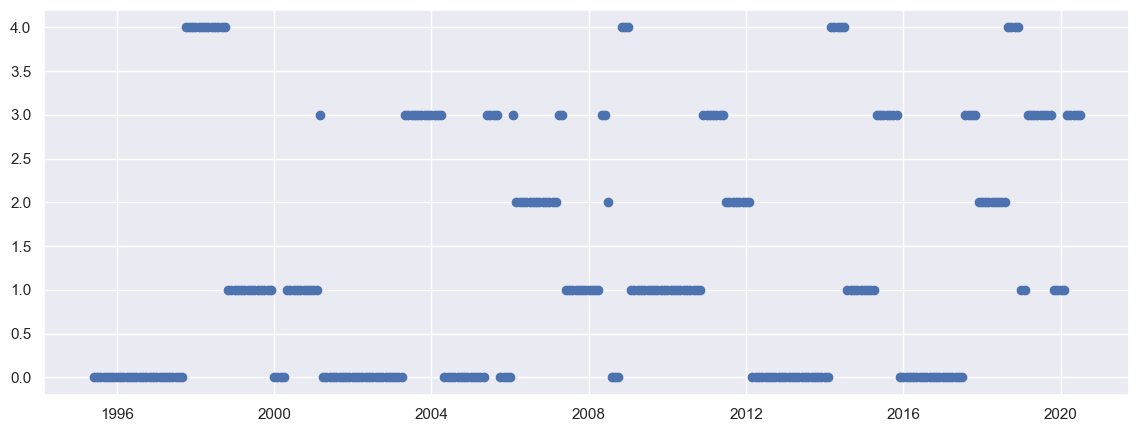

In [60]:
plt.figure(figsize=(14, 5))
#plt.scatter(df['time_centered'],eap_corr_category)
plt.scatter(df['time_centered'],case_cat)

In [24]:
per_var_nao      = []
per_var_eap      = []
nao_mode_no      = []
lon_subtrop_high = []
lon_eap_coa      = []
max_corr_nao     = []
max_lag_nao      = []
max_corr_eap     = []
max_lag_eap      = []